Heatmap tổng quát (không bao gồm các biến ý tế vì nó không có liên quan đến kinh tế)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../data/processed/merged_dataset.csv')

df.head()

,year,exports_percent_gdp,fdi_percent_gdp,gdp_growth,inflation_cpi,labor_force,unemployment,new_cases,new_deaths,total_cases,...,population,gdp_per_capita,life_expectancy,cases_per_capita,deaths_per_capita,fatality_rate,vaccination_rate,full_vaccination_rate,covid_intensity_index,covid_policy_shock
0,1985,0.000000,-0.000568,3.805856,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1986,6.622539,0.000152,2.789292,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1987,6.001428,0.028271,3.583470,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1988,3.945298,0.030208,5.135012,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1989,23.849358,0.064672,7.364513,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
corr_cols = [
    'exports_percent_gdp',
    'fdi_percent_gdp',
    'gdp_growth',
    'inflation_cpi',
    'labor_force',
    'unemployment',
    'gdp_per_capita',
    'stringency_index'
]

# ĐỔI TÊN HIỂN THỊ
rename_cols = {
    'exports_percent_gdp': 'XK/GDP',
    'fdi_percent_gdp': 'FDI/GDP',
    'gdp_growth': 'GDP Growth',
    'inflation_cpi': 'Lạm phát',
    'labor_force': 'Lực lượng LĐ',
    'unemployment': 'Thất nghiệp',
    'gdp_per_capita': 'GDP/người',
    'stringency_index': 'Mức độ siết chặt'
}

corr_df = df[corr_cols].rename(columns=rename_cols)

# TÍNH TƯƠNG QUAN
corr = corr_df.corr()

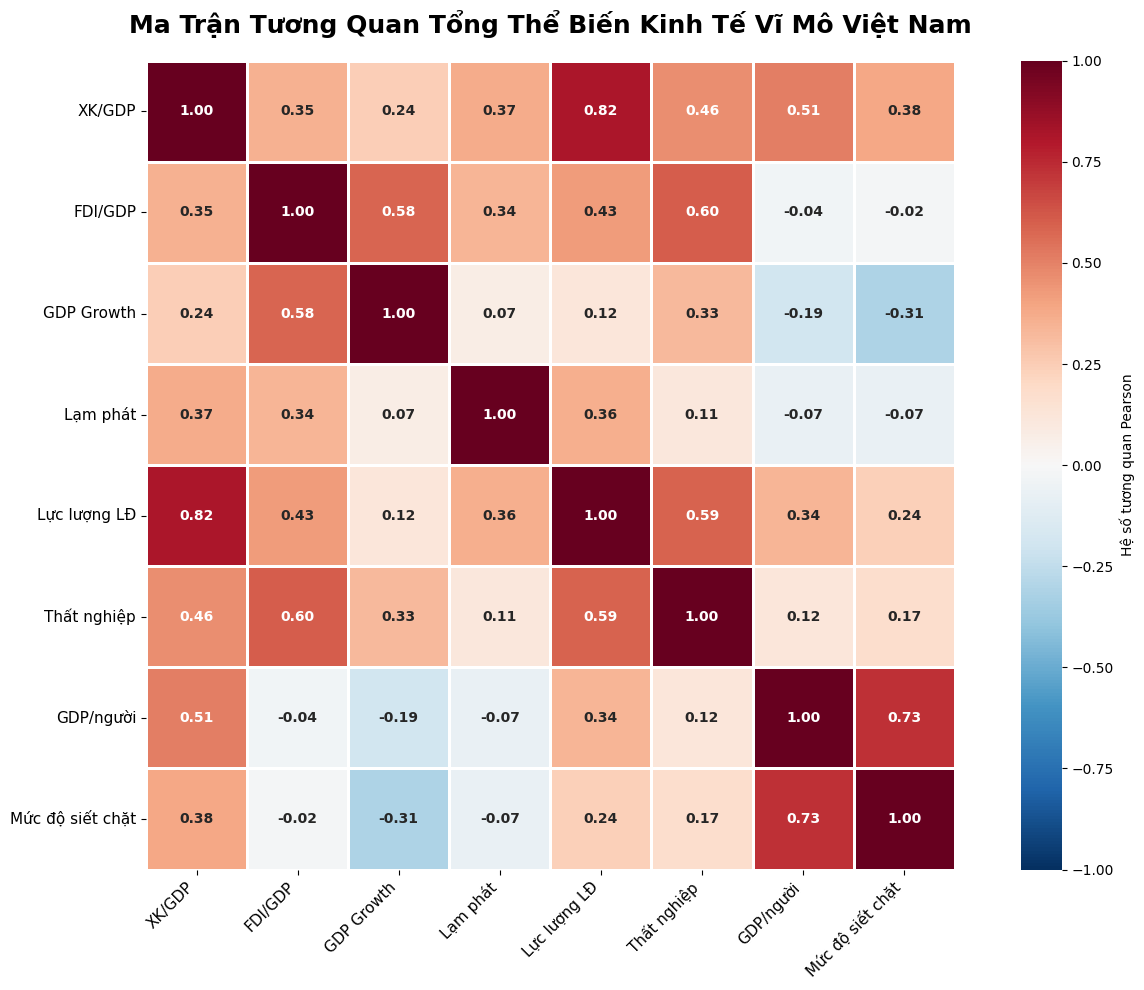

In [13]:
# VẼ HEATMAP
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    linewidths=1,
    square=True,
    annot_kws={
        'size': 10,
        'weight': 'bold'
    },
    cbar_kws={
        'label': 'Hệ số tương quan Pearson'
    }
)

plt.title(
    'Ma Trận Tương Quan Tổng Thể Biến Kinh Tế Vĩ Mô Việt Nam',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=11
)

plt.yticks(
    rotation=0,
    fontsize=11
)

plt.tight_layout()

plt.show()

Heatmap correlation cho thấy phần lớn các biến kinh tế vĩ mô có mối quan hệ hợp lý với nhau và phản ánh được đặc điểm của nền kinh tế Việt Nam trong giai đoạn nghiên cứu.

- XK/GDP có tương quan dương mạnh với lực lượng lao động (0.82), cho thấy sự mở rộng của hoạt động xuất khẩu thường đi kèm với nhu cầu lao động gia tăng.

- FDI/GDP có tương quan dương với GDP Growth (0.58), phản ánh vai trò quan trọng của đầu tư trực tiếp nước ngoài đối với tăng trưởng kinh tế Việt Nam.

- GDP Growth có tương quan âm với mức độ siết chặt COVID-19 (-0.31), cho thấy các biện pháp kiểm soát dịch bệnh đã tác động tiêu cực đến hoạt động kinh tế trong giai đoạn đại dịch.

- GDP/người có tương quan dương tương đối cao với mức độ siết chặt (0.73). Điều này có thể phản ánh xu hướng tăng trưởng kinh tế dài hạn song song với giai đoạn duy trì các chính sách kiểm soát dịch bệnh.

Ngoài ra, một số mối quan hệ có mức tương quan chưa hoàn toàn phù hợp với kỳ vọng kinh tế học, chẳng hạn FDI/GDP và thất nghiệp (0.60). Điều này có thể xuất phát từ tác động bất thường của COVID-19, độ trễ kinh tế hoặc giới hạn của dữ liệu theo năm.

Nhìn chung, heatmap giúp xác định các biến có mối liên hệ đáng chú ý, hỗ trợ cho bước lựa chọn biến trong các mô hình hồi quy và phân tích tác động của COVID-19 đến kinh tế Việt Nam.